
Selected days:
          date  morning_CF  evening_CF     score
40  2024-04-10    0.683372    0.322783  0.360589
41  2024-04-11    0.661565    0.326921  0.334644
44  2024-04-14    0.737365    0.408042  0.329324
28  2024-03-29    0.477287    0.190872  0.286415
37  2024-04-07    0.595695    0.337132  0.258563
10  2024-03-11    0.618348    0.378083  0.240265

Files exported:
d:\WORK\4_STUDENT_DTU\OneDrive - Danmarks Tekniske Universitet\12_Semesters\7_13week_course\46755_RenewablesInElectricityMarkets\0.CourseName_Assignments\Assignment1_MarketClearing\data\processed\wind_available_power_6_nodes_MW.csv
d:\WORK\4_STUDENT_DTU\OneDrive - Danmarks Tekniske Universitet\12_Semesters\7_13week_course\46755_RenewablesInElectricityMarkets\0.CourseName_Assignments\Assignment1_MarketClearing\data\processed\wind_capacity_factors_6_nodes.csv
d:\WORK\4_STUDENT_DTU\OneDrive - Danmarks Tekniske Universitet\12_Semesters\7_13week_course\46755_RenewablesInElectricityMarkets\0.CourseName_Assignments\Assignme

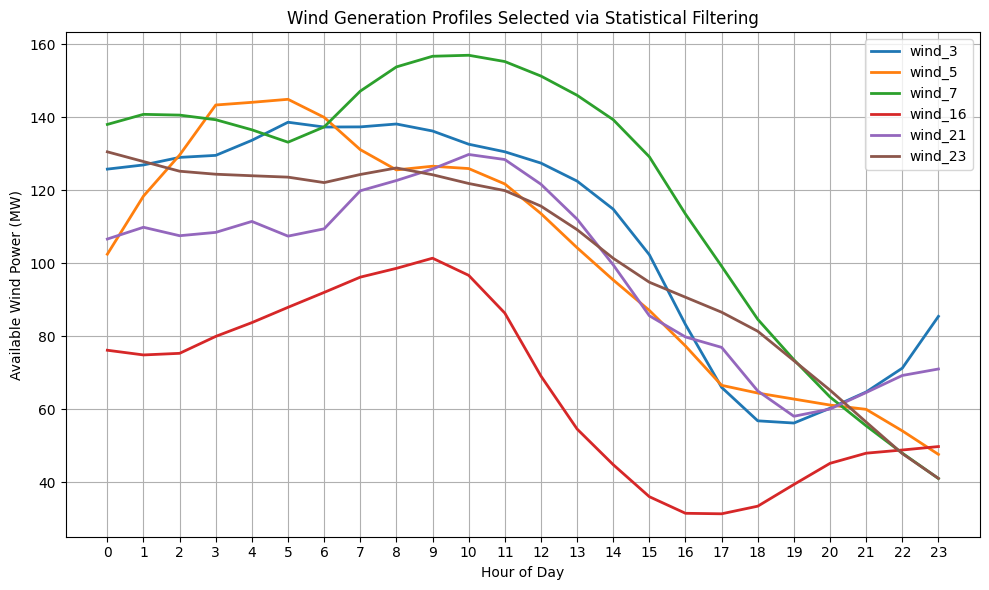

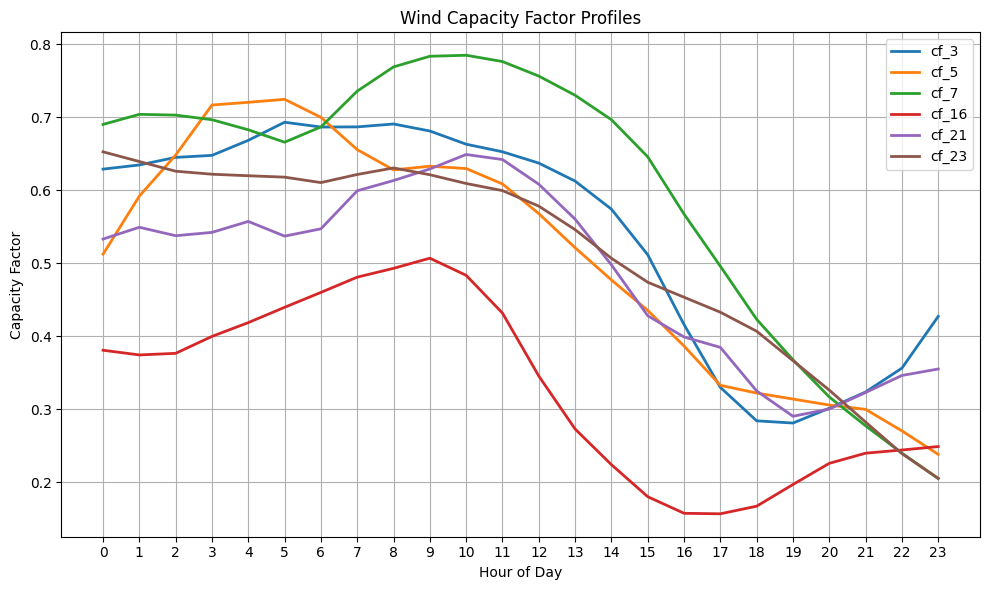

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# USER SETTINGS
# ============================================

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data", "raw", "NinjaRaw")

wind_file = os.path.join(
    DATA_DIR,
    "ninja-wind-country-DK-current_onshore-merra2.csv"
)

WIND_CAPACITY_PER_FARM = 200
wind_nodes = [3,5,7,16,21,23]

# ============================================
# LOAD DATA
# ============================================

df = pd.read_csv(wind_file, skiprows=3)

df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["hour"] = df["time"].dt.hour
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

# Use one year
df = df[df["year"] == 2024]

# Restrict to spring months
df = df[df["month"].isin([3,4,5])]

# ============================================
# DAILY STATISTICS
# ============================================

daily_stats = []

for d, group in df.groupby("date"):

    morning = group[group["hour"].between(5,10)]["NATIONAL"].mean()
    evening = group[group["hour"].between(16,21)]["NATIONAL"].mean()

    score = morning - evening

    daily_stats.append({
        "date": d,
        "morning_CF": morning,
        "evening_CF": evening,
        "score": score
    })

daily_stats = pd.DataFrame(daily_stats)

# ============================================
# SELECT BEST 6 DAYS
# ============================================

best_days = (
    daily_stats
    .sort_values("score", ascending=False)
    .head(6)
)

selected_days = best_days["date"].tolist()

print("\nSelected days:")
print(best_days)

# ============================================
# BUILD WIND PROFILES
# ============================================

wind_power_profiles = pd.DataFrame()
wind_power_profiles["hour"] = range(24)

wind_cf_profiles = pd.DataFrame()
wind_cf_profiles["hour"] = range(24)

node_day_mapping = []

for node, day in zip(wind_nodes, selected_days):

    day_df = (
        df[df["date"] == day]
        .sort_values("hour")
    )

    cf_profile = day_df["NATIONAL"].values
    power_profile = cf_profile * WIND_CAPACITY_PER_FARM

    wind_power_profiles[f"wind_{node}"] = power_profile
    wind_cf_profiles[f"cf_{node}"] = cf_profile

    node_day_mapping.append({
        "node": node,
        "selected_day": day
    })

node_day_mapping = pd.DataFrame(node_day_mapping)

# ============================================
# EXPORT CSV FILES
# ============================================

OUTPUT_DIR = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1️ Wind power (MW)
power_file = os.path.join(
    OUTPUT_DIR,
    "wind_available_power_6_nodes_MW.csv"
)

wind_power_profiles.to_csv(power_file, index=False)

# 2️ Capacity factors
cf_file = os.path.join(
    OUTPUT_DIR,
    "wind_capacity_factors_6_nodes.csv"
)

wind_cf_profiles.to_csv(cf_file, index=False)

# 3 Node-day mapping
mapping_file = os.path.join(
    OUTPUT_DIR,
    "wind_selected_days_per_node.csv"
)

node_day_mapping.to_csv(mapping_file, index=False)

print("\nFiles exported:")
print(power_file)
print(cf_file)
print(mapping_file)

# ============================================
# PLOT WIND POWER PROFILES
# ============================================

plt.figure(figsize=(10,6))

for col in wind_power_profiles.columns[1:]:
    plt.plot(
        wind_power_profiles["hour"],
        wind_power_profiles[col],
        linewidth=2,
        label=col
    )

plt.xlabel("Hour of Day")
plt.ylabel("Available Wind Power (MW)")
plt.title("Wind Generation Profiles Selected via Statistical Filtering")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# PLOT CAPACITY FACTORS
# ============================================

plt.figure(figsize=(10,6))

for col in wind_cf_profiles.columns[1:]:
    plt.plot(
        wind_cf_profiles["hour"],
        wind_cf_profiles[col],
        linewidth=2,
        label=col
    )

plt.xlabel("Hour of Day")
plt.ylabel("Capacity Factor")
plt.title("Wind Capacity Factor Profiles")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()